<a href="https://colab.research.google.com/github/Jun-0001/Audio-DL/blob/main/%EC%98%A4%EB%94%94%EC%98%A4_%EB%94%A5%EB%9F%AC%EB%8B%9D_%EA%B8%B0%EC%B4%88.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. 사인파

sine(사인) 파는 일정 주파수와 진폭을 갖는 주기 함수입니다. 수학적으로는 y = A * sin(2*pi*f*t + phi)와 같이 표현할 수 있으며, 여기서 A는 진폭, f는 주파수, t는 시간, phi는 위상 차이를 나타냅니다.

sine 파는 자연계에서 발생하는 다양한 현상을 모델링할 때 유용하게 사용됩니다. 예를 들어, 소리는 공기 분자의 진동으로 발생하는 파동 형태이며, sine 파의 형태로 모델링할 수 있습니다. 따라서 sine 파를 이용하여 다양한 소리를 만들어낼 수 있습니다.

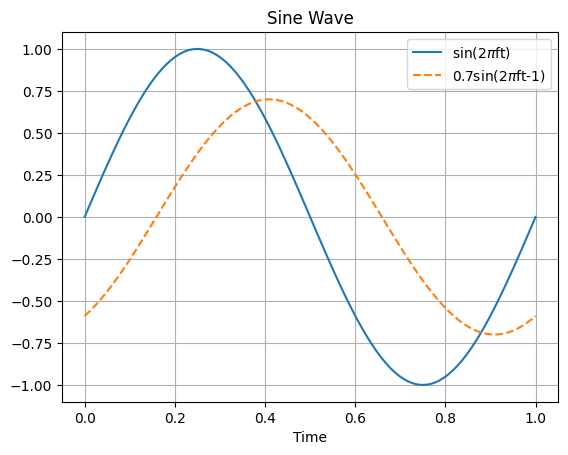

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 1, 100)
f = 1  # 1Hz

# 문자열 앞에 'r' (Raw string)을 붙여서 \pi 관련 경고를 제거합니다.
plt.plot(t, 1 * np.sin(2*np.pi*f*t + 0), "-",
         label=r'sin(2$\pi$ft)')
plt.plot(t, 0.7 * np.sin(2*np.pi*f*t - 1), ls="--",
         label=r'0.7sin(2$\pi$ft-1)')

plt.xlabel("Time")
plt.title("Sine Wave")
plt.legend()
plt.grid()
plt.show()

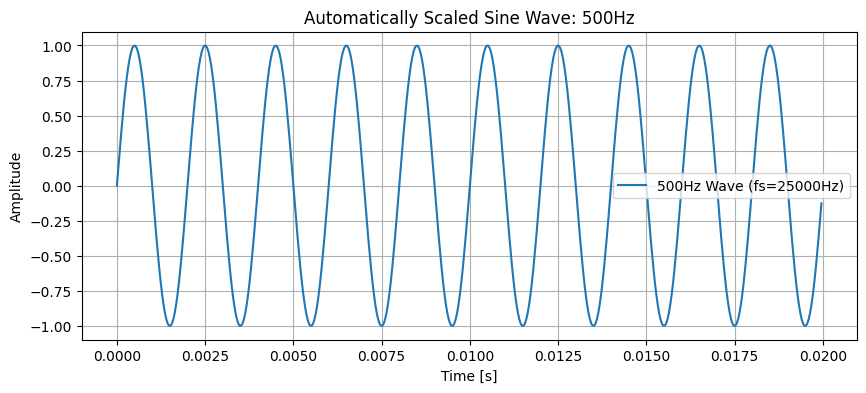

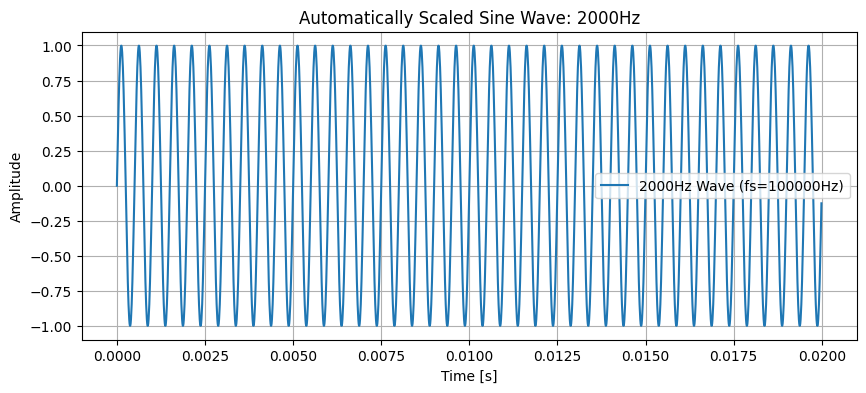

In [ ]:
def plot_sine_wave(f, duration=0.02):
    # 1. 자동 샘플링 설정: 주파수의 50배 정도로 점을 찍음 (매우 부드러움)
    fs = f * 50

    # 2. 시간축 생성: 0부터 duration(초)까지 fs 간격으로 생성
    t = np.arange(0, duration, 1/fs)

    # 3. 파형 생성
    y = np.sin(2 * np.pi * f * t)

    # 4. 시각화
    plt.figure(figsize=(10, 4))
    plt.plot(t, y, label=f'{f}Hz Wave (fs={fs}Hz)')
    plt.title(f"Automatically Scaled Sine Wave: {f}Hz")
    plt.xlabel("Time [s]")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.legend()
    plt.show()

# 이제 숫자만 바꾸면 알아서 그려집니다!
plot_sine_wave(500)   # 500Hz
plot_sine_wave(2000)  # 2000Hz (고음)

### fade in, fade out 구현 기능 구현

In [ ]:
def fade_io(data, length = 1000):
    # 0에서 1까지 선형적으로 증가하는 값 생성
    fade_in_data = np.linspace(0, 1, length)
    # Fade-in 적용
    data[:length] *= fade_in_data
    # 1에서 0까지 선형적으로 감소하는 값 생성
    fade_out_data = np.linspace(1, 0, length)
    # Fade-out 적용
    data[-length:] *= fade_out_data
    return data


### 사인파 들어보기

In [ ]:
#주파수와 실행시간을 인자로 받는 Sine 톤 함수 만들기
def sine_tone(f, duration=0.08, n=1280):
  t = np.linspace(0, duration, n)#fs = 1280/0.08 = 16kHz
  data = np.sin(2*np.pi*f*t)
  # length = 10**int(np.log10(n))
  # length = 10**int(np.log10(duration*n))


  # 전체의 10%만 페이드 처리 (약 8ms)
  length = int(n * 0.1)

  return fade_io(data = data, length = length)


### IPython.display.Audio 로 듣기

In [ ]:
from IPython.display import Audio
Audio(sine_tone(1000), rate=16000)


# 2. 사인파로 tone 만들기

A4 - A#4 - B4 - C5 - C#5 - D5 - D#5 - E5 - F5 - F#5 - G5 - G#5 - A5

A4는 440 Hz의 주파수를 갖습니다. 그리고 각 음계의 주파수는 반음 간격마다 2의 1/12 거듭제곱 배로 증가합니다. 따라서 A5의 주파수는 A4의 주파수 440 Hz에 반음 12개를 올라간 2의 12/12 거듭제곱(즉, 2배)을 곱한 880 Hz가 됩니다.

In [ ]:
from IPython.display import Audio

fs = 16000 #
scale = [440 * 2**(i/12) for i in range(5)]
# i=0 -> scale: 440..
# i=1 -> scale: 466..
# i=2 -> scale: 494..
# i=3 -> scale: 523..
# i=4 -> scale: 554..

# np.around(scale)#array([440., 466., 494., 523., 554.])
scale_tone = np.hstack([sine_tone(f) for f in scale])

Audio(scale_tone, rate = fs)


In [ ]:
octave = [440*(i+1) for i in range(5)]
#[440, 880, 1320, 1760, 2200]
# 0 - 1옥타브, 1.5옥타브, 2옥타브, 2.5옥타브
octave_tone = np.hstack([sine_tone(f) for f in octave])
Audio(octave_tone, rate = fs)


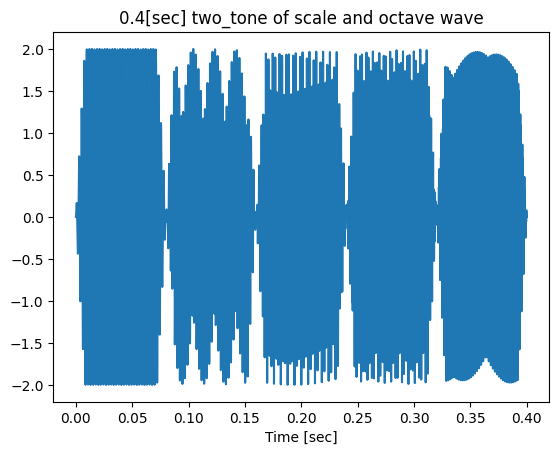

In [ ]:
two_tone_add = np.add(scale_tone, octave_tone)

plt.plot(np.linspace(0,len(two_tone_add)/fs,len(two_tone_add)),two_tone_add)
plt.xlabel(f"Time [sec]")
plt.title(f"{len(two_tone_add)/fs}[sec] two_tone of scale and octave wave")
plt.show()
print()


In [ ]:
Audio(two_tone_add, rate = fs)


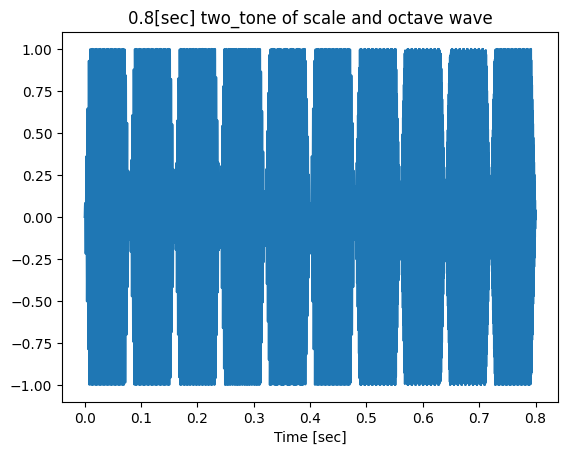

In [ ]:
two_tone_hstack = np.hstack([scale_tone, octave_tone])

plt.plot(np.linspace(0,len(two_tone_hstack)/fs,len(two_tone_hstack)),two_tone_hstack)
plt.xlabel(f"Time [sec]")
plt.title(f"{len(two_tone_hstack)/fs}[sec] two_tone of scale and octave wave")
plt.show()
print()


In [ ]:
Audio(two_tone_hstack, rate = fs)

# 03. FFT 및 시각화


In [ ]:
from scipy.fftpack import fft

class MyException(Exception):
    pass

def n_fft(data, n_lim=20):
  # 입력 데이터 길이 확인.
  for n in 2**np.arange(n_lim):
    if n >= len(data):
      return n
    if len(data) > 2**(n_lim-1) :
      raise MyException(f"increase 'n_lim' by more than '{n_lim}'!!")

data = two_tone_add

try:
  N = n_fft(data)
  print(f"data' {len(data)}', number for FFT '{N}'")
except MyException as e:
  print(e)

fs = 16000
Y = fft(data,N)#np.fft.fft(data, N)


data' 6400', number for FFT '8192'


/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


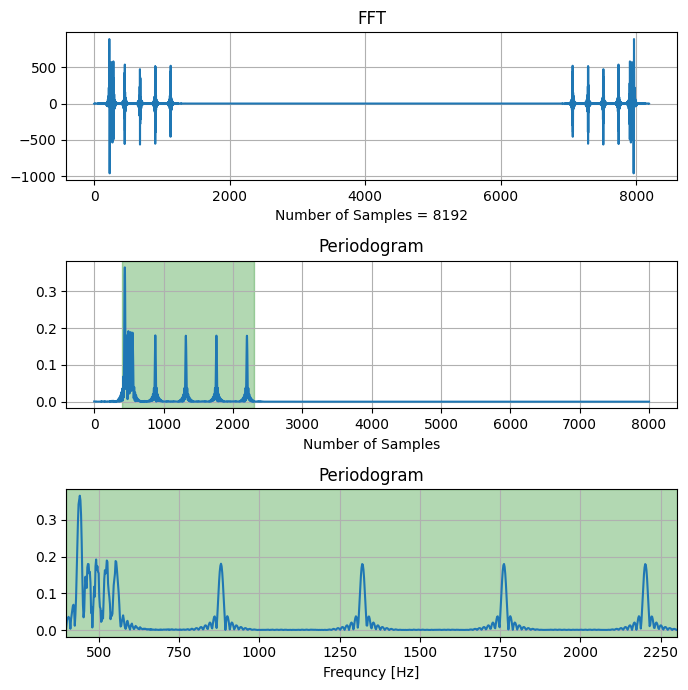

In [ ]:
plt.figure(figsize =(7,7))
plt.subplot(311)
plt.plot(np.arange(len(Y)), Y)#np.linspace(0, fs, N),
plt.title('FFT')
plt.xlabel(f'Number of Samples = {len(Y)}')
plt.grid()

plt.subplot(312)
#Periodogram(fft성분에 절대값을 취하고 대칭성분를 왼쪽으로 합치고 입력크기로 정규화)
plt.plot(np.linspace(0, fs/2, N//2), 2*np.abs(Y[:N//2])/len(data))
plt.xlabel('Number of Samples')
plt.title('Periodogram')
plt.grid()
plt.axvspan(400,2300, alpha=0.3, color='green')
#[440, 440.0, 466.0, 494.0, 523.0, 554.0, 880, 1320, 1760, 2200]

plt.subplot(313)
#x축을 주파수로 바꾸고 앞에서 표시한 구간 확대
plt.plot(np.linspace(0, fs/2, N//2), 2*np.abs(Y[:N//2])/len(data))
plt.xlabel('Frequncy [Hz]')
plt.title('Periodogram')
plt.grid()
plt.axvspan(400, 2300, alpha=0.3, color='green')
plt.xlim(400, 2300)#확대

plt.tight_layout()
plt.show()


In [ ]:
from scipy.fftpack import fft

class MyException(Exception):
    pass

def n_fft(data, n_lim=20):
  for n in 2**np.arange(n_lim):
    if n >= len(data):
      return n
    if len(data) > 2**(n_lim-1) :
      raise MyException(f"increase 'n_lim' by more than '{n_lim}'!!")

data = two_tone_hstack

try:
  N = n_fft(data)
  print(f"data' {len(data)}', number for FFT '{N}'")
except MyException as e:
  print(e)

fs = 16000
Y = fft(data,N)#np.fft.fft(data, N)


data' 12800', number for FFT '16384'


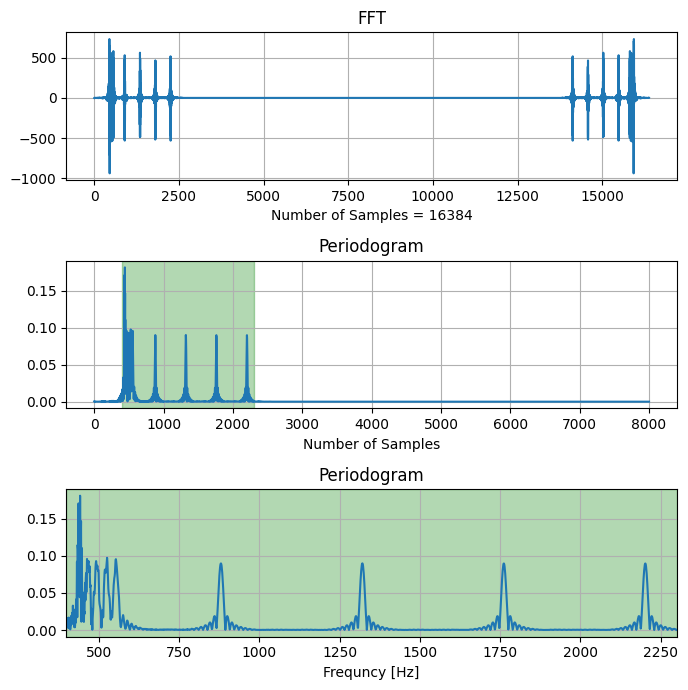

In [ ]:
plt.figure(figsize =(7,7))
plt.subplot(311)
plt.plot(np.arange(len(Y)), Y)#np.linspace(0, fs, N),
plt.title('FFT')
plt.xlabel(f'Number of Samples = {len(Y)}')
plt.grid()

plt.subplot(312)
#Periodogram(fft성분에 절대값을 취하고 대칭성분를 왼쪽으로 합치고 입력크기로 정규화)
plt.plot(np.linspace(0, fs/2, N//2), 2*np.abs(Y[:N//2])/len(data))
plt.xlabel('Number of Samples')
plt.title('Periodogram')
plt.grid()
plt.axvspan(400,2300, alpha=0.3, color='green')
#[440, 440.0, 466.0, 494.0, 523.0, 554.0, 880, 1320, 1760, 2200]

plt.subplot(313)
#x축을 주파수로 바꾸고 앞에서 표시한 구간 확대
plt.plot(np.linspace(0, fs/2, N//2), 2*np.abs(Y[:N//2])/len(data))
plt.xlabel('Frequncy [Hz]')
plt.title('Periodogram')
plt.grid()
plt.axvspan(400, 2300, alpha=0.3, color='green')
plt.xlim(400, 2300)#확대

plt.tight_layout()
plt.show()


# 4. Librosa 라이브러리

리브로사(librosa)는 음악 및 오디오 신호 처리를 위한 파이썬 라이브러리입니다. 이 라이브러리는 음악 분석, 오디오 신호 변환 및 기타 오디오 처리 작업을 수행하기 위한 다양한 기능을 제공합니다.

librosa의 기능 중 일부는 다음과 같습니다:

오디오 파일을 로드하고 저장하기 위한 함수
음악의 스펙트로그램, 멜 스펙트로그램 및 스펙트럼을 생성하는 함수
음악의 템포, 비트, 리듬 및 주파수를 추출하는 함수
음악 신호를 필터링하고 변환하는 함수
음악 데이터를 시각화하는 함수
librosa는 많은 머신 러닝 및 딥 러닝 모델에서 음악 분석 및 처리를 위해 사용되며, 음악 정보 검색, 음악 생성 및 음악 추천 시스템과 같은 다양한 분야에서 응용됩니다.

## 4.1 MFCC

MFCC는 Mel Frequency Cepstral Coefficients의 약어로, 음성 신호의 특징을 추출하는 기술 중 하나입니다. 이를 위해 일반적으로 다음과 같은 단계를 거칩니다.

1. STFT(Short Time Fourier Transform)에 의해 주어진 음성 신호를 작은 프레임 단위로 나누어서 주파수 영역의 데이터로 변환
2. Mel Filter Bank로 멜 스펙트럼을 계산
3. 로그 스케일링하고 DCT(Discrete Cosine Transfrom)을 수행
4. 이를 이용하여 해당 프레임의 특징을 추출

이때 추출된 특징은 일반적으로 MFCC 계수라고 부르며, 이후 음성 인식 및 음성 처리 분야에서 다양하게 활용됩니다.

## 4.2 MFCC 구현

In [ ]:
import librosa
import librosa.display
import IPython.display as ipd
import matplotlib.pyplot as plt
import numpy as np
import scipy.fftpack as fft
import seaborn as sns


# 0. 데이터 및 변수 설정 (fs와 data가 정의되어 있어야 함)
# 1초일 경우 데이터 16000개
# 0.08초일 경우 데이터 1280개
# 묶음 크기 2048
fs = 16000 # 데이터 위 16000개의 점찍기
data = two_tone_add
n_fft = 2048 # 정확히 말하면 2의 11승 즉, n=11인거지. 2048개 점을 한 묶음으로 본다
# 이 때 1025
hop = n_fft // 4 # 4로 나눈 몫 계산 512. 보폭이라고 생각하면 됨
# [13개 묶음의 탄생 원리: center=True 기준 중심점 이동]
# 1번 묶음 (중심=0):     -1024 ~ 1023번 인덱스 (앞은 0으로 채움)
# 2번 묶음 (중심=512):    -512 ~ 1535번 인덱스
# 3번 묶음 (중심=1024):      0 ~ 2047번 인덱스
# 4번 묶음 (중심=1536):    512 ~ 3071번 인덱스
# ... 중략 (512씩 계속 이동) ...
# 12번 묶음 (중심=5632):  4608 ~ 6655번 인덱스
# 13번 묶음 (중심=6144):  5120 ~ 7167번 인덱스 (뒤는 0으로 채움)
# 다음 중심은 6656인데, 이는 데이터 끝(6400)을 넘어갔으므로 13번에서 멈춤.


# 1. STFT 계산 (1025, 13)
# 1025 -> 세로축. 총 1025개의 칸. 각 칸은 약 8 Hz 간격
# 13 -> 가로축. 시간. 묶음
stft = librosa.stft(data, n_fft=n_fft, window='hann', hop_length=hop, center=True)

# 2. 파워 스펙트럼 (복소수 -> 실수)
# abs -> 절대값 -> 길이 -> 진폭
# **2 -> 제곱 -> 파워
# np.abs(stft)는 진폭(Amplitude)이고, 제곱하면 파워(Power)입니다.
power_spec = np.abs(stft)**2

# 3. Mel Filter Bank 계수 계산 (128, 1025)
# n_mels=128가 default값임
mel_f = librosa.filters.mel(sr=fs, n_fft=n_fft, n_mels=128)

# 4. Mel Spectrogram 계산 (행렬 곱: 128, 1025 X 1025, 13 = 128, 13)
# mel_f X power_spec
mel_spec = np.dot(mel_f, power_spec)

# 5. 로그 스케일 변환 (librosa.power_to_db 권장)
# 직접 np.log10을 하면 0값 때문에 -inf가 발생하여 에러의 원인이 됩니다.
log_mel_spec = librosa.power_to_db(mel_spec)

# 6. DCT 계산 (MFCC 추출: 20, 13)
n_mfcc = 20
# axis=0 (주파수 축) 방향으로 변환 후 상위 n_mfcc개만 슬라이싱
mfcc = fft.dct(log_mel_spec, axis=0, norm='ortho')[:n_mfcc]

# 결과 출력
print(f'stft.shape: {stft.shape}')
print(f'mel_f.shape: {mel_f.shape}')
print(f'log_mel_spec.shape: {log_mel_spec.shape}')
print(f'mfcc.shape: {mfcc.shape}')

stft.shape: (1025, 13)
mel_f.shape: (128, 1025)
log_mel_spec.shape: (128, 13)
mfcc.shape: (20, 13)


In [ ]:
# stft 데이터 타입 확인

# 1. 데이터 타입(dtype) 확인 -> 'complex64' 또는 'complex128'이 나와야 함
print(f"STFT 데이터 타입: {stft.dtype}")

# 2. 첫 번째 칸의 실제 값 출력 (복소수 형태 확인)
print(f"첫 번째 원소 (0,0)의 값: {stft[0, 0]}")

# 3. 허수부(Imaginary part)만 따로 뜯어보기
# np.imag() 결과가 0이 아니라면 복소수가 확실합니다.
print(f"첫 번째 원소의 허수부: {np.imag(stft[0, 0])}")

# 4. 전체 행렬에 복소수가 포함되어 있는지 체크
print(f"전체 데이터 중 복소수가 있는가? : {np.iscomplex(stft).any()}")

STFT 데이터 타입: complex128
첫 번째 원소 (0,0)의 값: (0.01953723118374484+0j)
첫 번째 원소의 허수부: 0.0
전체 데이터 중 복소수가 있는가? : True


In [ ]:
import numpy as np

# 1. 전체 행렬의 데이터 타입 확인 (complex 확인)
print(f"STFT 타입: {stft.dtype}")

# 2. 특정 위치의 복소수 값 확인
sample_val = stft[10, 5] # 10번 주파수 칸, 5번 시간 묶음
print(f"원래 복소수 값: {sample_val}")

# 3. .real과 .imag 속성으로 뜯어보기
print(f"실수부(Real): {sample_val.real}")
print(f"허수부(Imag): {sample_val.imag}") # <--- 이게 바로 보고 싶으셨던 그 '허수'입니다!

# 4. 행렬 전체를 허수부로만 만들기
stft_imag = np.imag(stft)
print("\n--- 허수부 행렬 일부 (1025, 13) ---")
print(stft_imag[:5, :5]) # 상단 5x5 영역만 출력

STFT 타입: complex128
원래 복소수 값: (-0.05080522587592+0.01972564053542444j)
실수부(Real): -0.05080522587592
허수부(Imag): 0.01972564053542444

--- 허수부 행렬 일부 (1025, 13) ---
[[ 0.          0.          0.          0.          0.        ]
 [-0.0281377  -0.18934603 -0.64437707  0.70780679 -0.08862916]
 [ 0.05008416 -0.22256584  0.89328076 -0.84715137  0.15340415]
 [-0.05993728  0.0192002  -0.67121678  0.40861001  0.23044467]
 [ 0.05770962  0.17460443  0.28981399  0.08834008 -0.07905787]]


<function matplotlib.pyplot.show(close=None, block=None)>

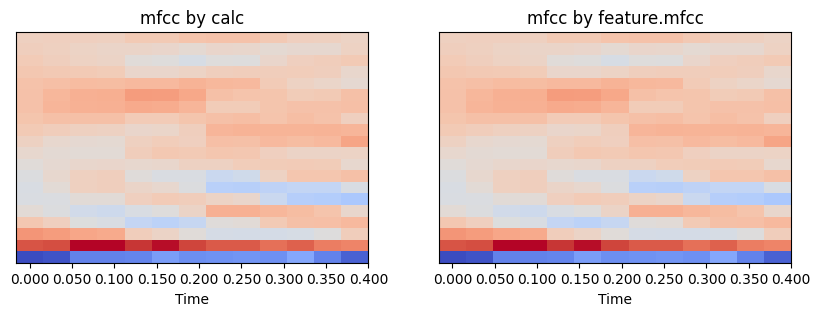

In [ ]:
plt.figure(figsize=(10,3))
plt.subplot(121)
librosa.display.specshow(mfcc, x_axis='time', sr=fs)
plt.title('mfcc by calc')

data = two_tone_add
mfcc_f = librosa.feature.mfcc(y=data, sr=fs, n_mfcc=n_mfcc)
plt.subplot(122)
librosa.display.specshow(mfcc_f, x_axis='time', sr=fs)
plt.title('mfcc by feature.mfcc')
plt.show


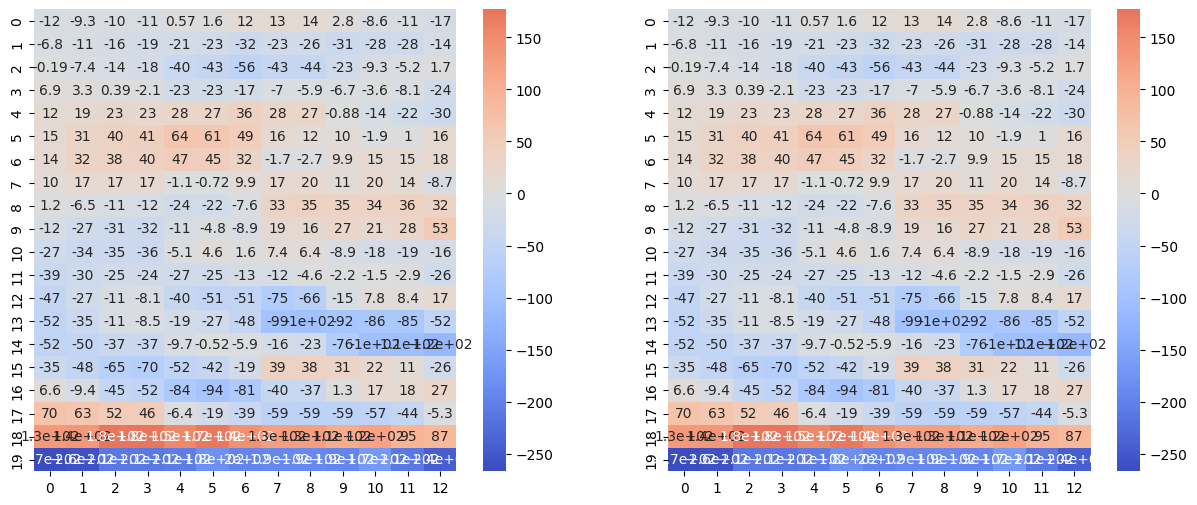

In [ ]:
plt.figure(figsize=(15,6))
plt.subplot(121)
sns.heatmap(mfcc[::-1], center=0., cmap='coolwarm',annot=True)

mfcc_f = librosa.feature.mfcc(y=data, sr=fs, n_mfcc=n_mfcc)
plt.subplot(122)
sns.heatmap(mfcc_f[::-1], center=0., cmap='coolwarm', annot=True)

plt.show()


In [ ]:
print(f"진짜 데이터 개수: {len(data)}")
print(f"이론적 시간: {len(data) / fs}초")

진짜 데이터 개수: 6400
이론적 시간: 0.4초


# 4.4 Spectrogram & Mel Spectrogram

이 코드는 librosa를 사용하여 Sine 파로 만든 two_tone 데이터의 스펙트로그램과 멜 스펙트로그램을 시각화하는 코드입니다.

1.   librosa.stft를 통해 STFT 계산
2.   np.abs로 STFT의 절대값 구함
3.   데이터 주파수 성분 파악 가능
4.   librosa.amplitude_to_db를 통해 STFT 절대값 -> 데시벨 단위로 변환
5.   librosa.display.specshow로 데시벨 변환 된 STFT를 시각화
6.   데이터 주파수 성분 파악 가능
7.   librosa.feature.melspectrogram를 통해 멜 스펙트로그램 계산
8.   librosa.power_to_db로 멜 스펙트로그램을  데시벨 변환 후 시각화

두 그림을 서브플롯으로 나란히 시각화하고, 각각의 y축 범위를 0Hz에서 3000Hz까지로 설정합니다. 마지막으로 plt.tight_layout() 함수를 사용하여 서브플롯 간의 간격을 조정하고, plt.show() 함수를 사용하여 그래프를 표시합니다.

ref=np.max는 librosa.amplitude_to_db() 함수에서 진폭 스케일링 기준을 나타내는 인수입니다. 이 인수가 np.max로 설정되면, STFT 데이터의 최대 진폭 값이 스케일링 기준이 됩니다. 즉, STFT 데이터의 진폭이 최대 값으로 정규화됩니다.

따라서 ref=np.max로 설정하면, 스펙트로그램에서 최대 진폭을 가진 주파수의 값이 0dB가 됩니다. 이것은 일반적으로 스펙트로그램을 시각화하거나 분석할 때 매우 유용합니다. 예를 들어, 오디오 신호를 시각화하거나 음악 장르 분류와 같은 머신 러닝 작업에서 입력 데이터를 정규화하기 위해 사용됩니다.



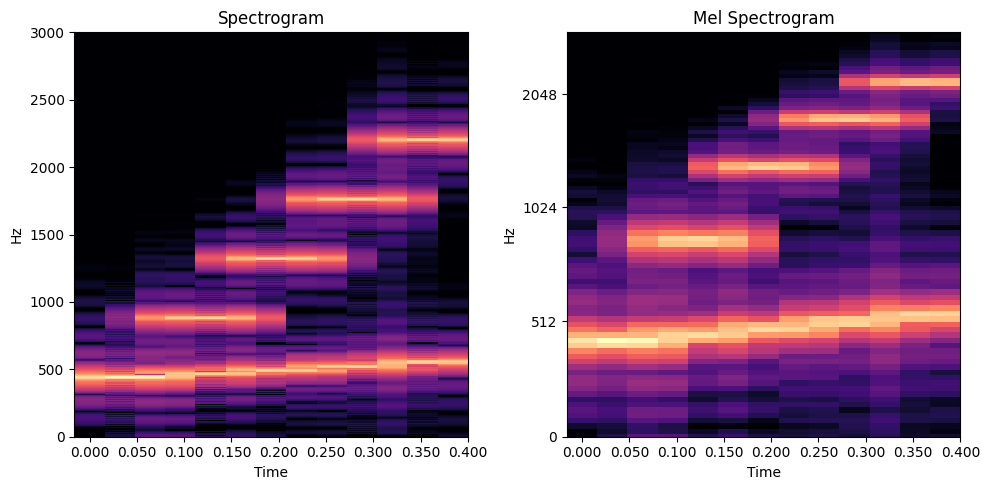

In [ ]:
import librosa
import librosa.display

data = two_tone_add
plt.figure(figsize=(10,5))

plt.subplot(121)
d_stft = np.abs(librosa.stft(data))
librosa.display.specshow(librosa.amplitude_to_db(d_stft, ref=np.max), sr=fs, y_axis='linear', x_axis='time')
plt.title('Spectrogram')
plt.ylim(0, 3000)

plt.subplot(122)
d_msp = librosa.feature.melspectrogram(y=data, sr=fs, n_mels=128)
librosa.display.specshow(librosa.power_to_db(d_msp, ref=np.max), sr=fs, y_axis='mel', x_axis='time')
plt.ylim(0, 3000)
plt.title('Mel Spectrogram')

plt.tight_layout()
plt.show()


## 🛠 `librosa.resample` 핵심 파라미터 가이드

리샘플링(Resampling)은 오디오 분석 파이프라인의 **첫 번째 관문(Step 1)**입니다. 데이터의 해상도를 통일하여 모델의 일관성을 보장하는 필수 전처리 과정입니다.

# librosa.resample(y, orig_sr, target_sr, res_type='kaiser_best', fix=True, scale=False)


---

### 📋 파라미터 상세 설명

| 매개변수 | 타입 | 기본값 | 상세 설명 |
| :--- | :--- | :--- | :--- |
| **`y`** | `ndarray` | **필수** | 리샘플링할 원본 오디오 시계열 데이터 |
| **`orig_sr`** | `int` | **필수** | 원본 데이터의 샘플링 레이트 (Hz) |
| **`target_sr`** | `int` | **필수** | 변환하고자 하는 목표 샘플링 레이트 (Hz) |
| **`res_type`** | `str` | `'kaiser_best'` | 사용할 필터 알고리즘 (품질 vs 속도 결정) |
| **`fix`** | `bool` | `True` | `True`일 경우, 출력 데이터의 길이를 원본 비율에 맞게 강제 고정 |
| **`scale`** | `bool` | `False` | `True`일 경우, 리샘플링 후 신호의 전체 에너지(RMS)를 보존하도록 크기 조정 |

---

### 🔍 주요 설정 포인트

#### 1. `res_type` 알고리즘 선택
* **`kaiser_best`**: 품질 최우선 모드. 앨리어싱(Aliasing) 현상을 최소화하며, 연구용이나 최종 결과물 생성 시 권장됩니다. (연산 시간 다소 소요)
* **`kaiser_fast`**: 속도 최우선 모드. 대용량 데이터셋 전처리 시 학습 속도를 높이기 위해 주로 사용됩니다.

#### 2. `fix=True` (기본값)
* 리샘플링 시 발생하는 미세한 샘플 수 차이(소수점 버림 등)를 보정하여, 전체 재생 시간(sec)이 변하지 않도록 길이를 맞춰줍니다.

#### 3. `scale=False` (기본값)
* 일반적으로 신호의 크기를 그대로 유지합니다. 만약 리샘플링 전후의 물리적 에너지 총량을 완벽히 일치시켜야 하는 특수 실험 시에만 `True`를 사용합니다.

---

In [ ]:
import librosa

# 1. 내장 예시 파일(트럼펫)의 경로 가져오기
filename = librosa.ex('trumpet')

# 2. 원본 파일 로드 (sr=None으로 설정하면 원본 SR 그대로 읽어옵니다)
y, sr = librosa.load(filename, sr=None)

# 3. 리샘플링 수행 (예: 22050Hz -> 11025Hz로 반토막 내기)
target_sr = 11025
y_resampled = librosa.resample(y, orig_sr=sr, target_sr=target_sr)

# 4. 결과 확인
print(f"원본 샘플링 레이트: {sr} Hz")
print(f"목표 샘플링 레이트: {target_sr} Hz")
print("-" * 30)
print(f"원본 데이터 길이: {len(y)} 샘플")
print(f"리샘플링 후 데이터 길이: {len(y_resampled)} 샘플")

원본 샘플링 레이트: 22050 Hz
목표 샘플링 레이트: 11025 Hz
------------------------------
원본 데이터 길이: 117601 샘플
리샘플링 후 데이터 길이: 58801 샘플


## ✂️ `librosa.effects.trim` 핵심 파라미터 가이드

`trim` 함수는 오디오 신호의 **앞뒤에 포함된 불필요한 무음(Silence)이나 정적**을 자동으로 감지하여 잘라내는 전처리 도구입니다. 데이터의 유효한 구간에만 집중하게 하여 AI 모델의 학습 효율을 높여줍니다.

---

### 📋 파라미터 상세 설명

| 매개변수 | 타입 | 기본값 | 상세 설명 |
| :--- | :--- | :--- | :--- |
| **`y`** | `ndarray` | **필수** | 무음을 제거할 원본 오디오 신호 |
| **`top_db`** | `int` | `60` | **무음 판정 임계값(dB).** 최대 진폭 대비 이 값보다 낮으면 무음으로 간주 |
| **`frame_length`**| `int` | `2048` | 에너지를 계산할 프레임의 길이 |
| **`hop_length`** | `int` | `512` | 프레임을 이동시키는 간격 (보폭) |

---

### 🔍 주요 설정 포인트

#### 1. `top_db` (임계값 설정)
* **숫자가 작을수록 (예: 20dB):** 기준이 엄격해져서 조금만 조용해도 다 잘라버립니다. (유효 신호가 잘릴 위험 있음)
* **숫자가 클수록 (예: 80dB):** 기준이 완만해져서 아주 미세한 소리도 살려둡니다. (무음이 덜 잘릴 수 있음)
* **💡 Tip:** 배경 소음이 큰 환경에서 녹음된 데이터라면 `top_db`를 낮춰서 조정해야 합니다.

#### 2. 반환값(Return)의 특징
* 이 함수는 **`(trimmed_y, index)`** 두 가지를 튜플 형태로 반환합니다.
    * `trimmed_y`: 무음이 제거된 실제 오디오 데이터
    * `index`: 원본에서 어느 지점이 잘렸는지 나타내는 시작과 끝 인덱스 `[start, end]`

---

In [ ]:
import librosa

# 예제 오디오 신호
y, sr = librosa.load(filename, sr=None)

# 오디오 신호 자르기
y_trimmed, index = librosa.effects.trim(y, top_db=30)

# 결과 출력
print("원본 신호 길이:", len(y))
print("잘린 신호 길이:", len(y_trimmed))


원본 신호 길이: 117601
잘린 신호 길이: 67584


## 📏 `librosa.util.fix_length` 핵심 가이드

`fix_length` 함수는 오디오 데이터의 길이를 **특정 크기로 고정**할 때 사용합니다. 딥러닝 모델은 입력 데이터의 크기가 모두 일정해야 하므로, 전처리 과정에서 매우 중요한 역할을 합니다.

### librosa.util.fix_length(x, size=size, axis=-1,  **kwargs)


---

### 📋 파라미터 상세 설명

| 매개변수 | 타입 | 기본값 | 상세 설명 |
| :--- | :--- | :--- | :--- |
| **`x`** | `ndarray` | **필수** | 길이를 고정할 원본 데이터 (배열) |
| **`size`** | `int` | **필수** | 목표로 하는 고정 길이 (샘플 수) |
| **`axis`** | `int` | `-1` | 고정할 축 (기본값은 마지막 축) |
| **`mode`** | `str` | `'constant'` | 부족한 길이를 채우는 방식 (패딩 모드) |
| **`constant_values`**| `float` | `0` | `mode='constant'`일 때 채울 값 (주로 0) |

---

### 🔍 주요 동작 원리

1. **데이터가 목표(size)보다 클 경우:**
   - 설정된 길이만큼만 남기고 뒤쪽을 **잘라냅니다(Truncate).**
2. **데이터가 목표(size)보다 작을 경우:**
   - 부족한 만큼 뒤쪽에 **패딩(Padding)**을 추가하여 길이를 늘립니다.

#### 💡 다양한 패딩 모드 (`mode`)
* **`constant`**: 지정한 상수(주로 0)로 채웁니다. (**가장 많이 사용**)
* **`edge`**: 데이터의 마지막 값으로 나머지 부분을 채웁니다.
* **`wrap`**: 원본 데이터를 반복(복사)하여 채웁니다.
* **`reflect` / `symmetric`**: 원본 데이터를 거울처럼 반사시켜 채웁니다.



---


In [ ]:
import librosa
import numpy as np

# librosa는 기본적으로 numpy 배열을 다루므로 np.array로 감싸주는 것이 좋습니다.
x = np.array([1, 2, 3, 4, 5])

# 핵심: 숫자 7 앞에 'size='를 반드시 붙여주어야 합니다.
fixed_x = librosa.util.fix_length(x, size=7)

print(fixed_x)  # 출력: [1 2 3 4 5 0 0]

[1 2 3 4 5 0 0]


## 📁 `librosa.load` vs `librosa.core.load` 완벽 비교

오디오 파일을 파이썬으로 읽어오는 가장 기본적인 단계입니다. 현재 `librosa`에서는 `librosa.load`를 사용하는 것이 표준이며, 더 유연한 기능을 제공합니다.

---

### 📋 함수별 주요 특징 및 차이점

| 구분 | `librosa.core.load` | `librosa.load` (권장) |
| :--- | :--- | :--- |
| **기본 역할** | 오디오 파일을 NumPy 배열로 로드 | `core.load`를 래핑한 고수준 API |
| **확장성** | 정해진 인자만 수용 | `**kwargs`를 통해 추가 설정 가능 |
| **단위 유연성** | `offset`, `duration`을 **초(sec)** 단위로만 지정 | 초 단위 외에 **샘플(sample)** 단위 지정 가능 |
| **리샘플링** | 기본적인 `res_type` 제공 | 더 다양하고 정밀한 리샘플링 방식 지원 |

---

### 🔍 파라미터 상세 설명

| 매개변수 | 의미 | 설명 |
| :--- | :--- | :--- |
| **`path`** | 파일 경로 | 로딩하려는 오디오 파일의 위치 |
| **`sr`** | 샘플링 주파수 | `None`일 경우 원본 유지, 숫자 지정 시 해당 값으로 자동 리샘플링 |
| **`mono`** | 채널 통합 | `True` 설정 시 스테레오 음원을 모노로 병합 |
| **`offset`** | 시작 지점 | 파일의 어느 지점부터 읽을지 결정 |
| **`duration`** | 지속 시간 | 시작 지점부터 얼마만큼 읽을지 결정 |
| **`res_type`** | 리샘플링 방식 | `kaiser_best`(고품질), `kaiser_fast`(속도) 등 선택 |

---

### 💡 핵심 포인트: 샘플(Sample) 단위 지정의 이점
`librosa.load`를 사용하면 오디오를 초 단위가 아닌 샘플 개수 단위로 정밀하게 잘라올 수 있습니다.
* **예시:** 샘플 레이트가 `22,050Hz`일 때, 정확히 1초 지점부터 읽고 싶다면 `offset=22050` (샘플 단위)으로 지정하여 물리적인 오차 없는 정밀 제어가 가능합니다.

---

In [ ]:
!pip install resampy


In [ ]:
import librosa

# 1. 파일 경로 설정 (내장 데이터를 예시로 사용)
filename = librosa.ex('trumpet')

# 2. 오디오 파일 로드
# sr=16000: 16kHz로 리샘플링하며 로드
# mono=True: 스테레오일 경우 모노로 합침
# offset=1.0, duration=2.0: 1초 지점부터 2초 동안만 읽기
y, sr = librosa.load(
    filename,
    sr=16000,
    mono=True,
    offset=1.0,
    duration=2.0,
    res_type='kaiser_fast'  # 속도가 빠른 리샘플링 방식 선택
)

# 3. 로드 결과 확인
print(f"샘플링 레이트(SR): {sr} Hz")
print(f"데이터 길이: {len(y)} 샘플")
print(f"재생 시간: {len(y)/sr} 초")

샘플링 레이트(SR): 16000 Hz
데이터 길이: 32000 샘플
재생 시간: 2.0 초


# 이후 실제 모델 과정은 캐글에서 진행...